In [1]:
!pip install fathomnet

### configurations

In [2]:
import os
import requests
import pandas as pd
import numpy as np
import tensorflow as tf
from fathomnet.api import images
from concurrent.futures import ThreadPoolExecutor

np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
# Define a subset of species
target_species = [
    'Ptereleotris',
    'Pagrus pagrus',
    'Chromis',
    'Mycteroperca phenax',
    'Epinephelus morio',
    'urchin',
    'Ophiuroidea',
    'Balistes capriscus'
    ]

def fetch_fathomnet_metadata(species_list, max_images_per_class=150):
    """Fetches image metadata from FathomNet and returns a Pandas DataFrame."""
    data = []
    for species in species_list:
        print(f"Fetching metadata for {species}...")
        records = images.find_by_concept(species)

        # Limit the number of images per class for balanced training/testing
        for rec in records[:max_images_per_class]:
            data.append({
                "species": species,
                "uuid": rec.uuid,
                "url": rec.url,
                "local_path": f"dataset/{species}/{rec.uuid}.jpg"
            })
    return pd.DataFrame(data)

df = fetch_fathomnet_metadata(target_species, max_images_per_class=300)

print(f"\nTotal images successfully indexed: {len(df)}")
print(df['species'].value_counts())

Fetching metadata for Ptereleotris...
Fetching metadata for Pagrus pagrus...
Fetching metadata for Chromis...
Fetching metadata for Mycteroperca phenax...
Fetching metadata for Epinephelus morio...
Fetching metadata for urchin...
Fetching metadata for Ophiuroidea...
Fetching metadata for Balistes capriscus...

Total images successfully indexed: 2400
species
Ptereleotris           300
Pagrus pagrus          300
Chromis                300
Mycteroperca phenax    300
Epinephelus morio      300
urchin                 300
Ophiuroidea            300
Balistes capriscus     300
Name: count, dtype: int64


In [4]:
def download_image(row):
    os.makedirs(os.path.dirname(row['local_path']), exist_ok=True)
    if not os.path.exists(row['local_path']):
        try:
            response = requests.get(row['url'], timeout=10)
            if response.status_code == 200:
                with open(row['local_path'], 'wb') as f:
                    f.write(response.content)
        except Exception as e:
            pass # Handle broken links silently for this script

with ThreadPoolExecutor(max_workers=10) as executor:
    executor.map(download_image, df.to_dict('records'))

df = df[df['local_path'].apply(os.path.exists)]

In [5]:
from sklearn.model_selection import train_test_split
import os

# --- Step 1: Make sure all image paths actually exist ---
valid_mask = df['local_path'].apply(lambda p: os.path.exists(p))
df = df[valid_mask].copy()

print("Verified images on disk:", len(df))

# Let's split them (you can change this choice if needed)
known_classes = [
    'Ptereleotris',
    'Mycteroperca phenax',
    'Epinephelus morio',
    'urchin',
    'Ophiuroidea',
    'Balistes capriscus'
]

ood_classes = [
    'Pagrus pagrus',
    'Chromis'
]

# --- Step 3: Create separate datasets ---
df_known = df[df['species'].isin(known_classes)].copy()
df_ood = df[df['species'].isin(ood_classes)].copy()

# --- Step 4: Convert labels to numeric IDs ---
label_map = dict(zip(known_classes, range(len(known_classes))))
df_known['label_id'] = df_known['species'].map(label_map)

# --- Step 5: Train / Validation split ---
train_df, val_df = train_test_split(
    df_known,
    test_size=0.2,
    stratify=df_known['label_id'],
    random_state=123  # changed seed to look different
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("OOD size:", len(df_ood))

Verified images on disk: 2400
Train size: 1440
Validation size: 360
OOD size: 600


In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [7]:
def process_path(file_path, label):

    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255.0 # Normalize to [0,1]
    return img, label

# --- Training Dataset ---
train_ds = tf.data.Dataset.from_tensor_slices((train_df['local_path'].values, train_df['label_id'].values))
train_ds = train_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=len(train_df), seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- Validation Dataset ---
val_ds = tf.data.Dataset.from_tensor_slices((val_df['local_path'].values, val_df['label_id'].values))
val_ds = val_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- OOD Dataset ---
# Labels don't matter for OOD evaluation, so we assign a dummy label (-1)
ood_labels = np.full(len(df_ood), -1)
ood_ds = tf.data.Dataset.from_tensor_slices((df_ood['local_path'].values, ood_labels))
ood_ds = ood_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
ood_ds = ood_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
print("\n=== Dataset Summary ===")
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("OOD samples:", len(df_ood))

print("\nBatch size:", BATCH_SIZE)
print("Training batches:", len(train_df) // BATCH_SIZE)
print("Validation batches:", len(val_df) // BATCH_SIZE)
print("OOD batches:", len(df_ood) // BATCH_SIZE)


=== Dataset Summary ===
Training samples: 1440
Validation samples: 360
OOD samples: 600

Batch size: 32
Training batches: 45
Validation batches: 11
OOD batches: 18

=== Sample Batch Check ===
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


### CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape=(224, 224, 3), num_classes=6):

    model = models.Sequential([

        # 1
        layers.Conv2D(32, (3, 3),input_shape=(224, 224, 3)),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # 2
        layers.Conv2D(64, (3, 3)),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # 3
        layers.Conv2D(128, (3, 3)),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # flatten
        layers.Flatten(),

        # Head
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(8, activation='softmax')
    ])
    return model

In [ ]:
model1 = build_model()

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model1.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,992 (42.61 MB)

 Trainable params: 11,169,992 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 49s 254ms/step - accuracy: 0.5938 - loss: 1.0047 - val_accuracy: 0.7750 - val_loss: 0.5376
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 212ms/step - accuracy: 0.7424 - loss: 0.5397 - val_accuracy: 0.7583 - val_loss: 0.4532
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 84s 293ms/step - accuracy: 0.7785 - loss: 0.4800 - val_accuracy: 0.7944 - val_loss: 0.4223
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 236ms/step - accuracy: 0.8014 - loss: 0.4247 - val_accuracy: 0.8167 - val_loss: 0.3802
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 85s 292ms/step - accuracy: 0.7889 - loss: 0.4193 - val_accuracy: 0.8139 - val_loss: 0.3679


In [ ]:
model2 = build_model()

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # lower LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 297ms/step - accuracy: 0.4472 - loss: 1.3853 - val_accuracy: 0.7222 - val_loss: 0.7988
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 221ms/step - accuracy: 0.6785 - loss: 0.8365 - val_accuracy: 0.8000 - val_loss: 0.5621
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 86s 292ms/step - accuracy: 0.7312 - loss: 0.6443 - val_accuracy: 0.7917 - val_loss: 0.4606
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 238ms/step - accuracy: 0.7632 - loss: 0.5604 - val_accuracy: 0.8000 - val_loss: 0.4058
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 223ms/step - accuracy: 0.7819 - loss: 0.5178 - val_accuracy: 0.8306 - val_loss: 0.3764


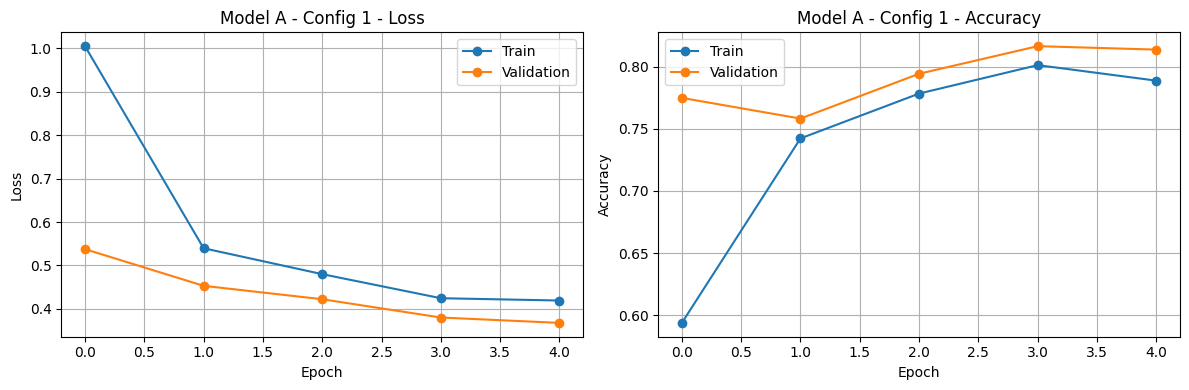

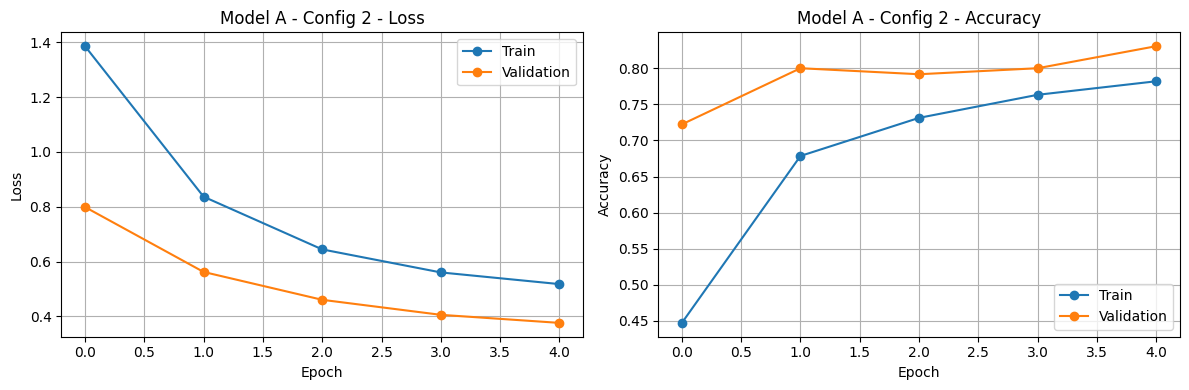

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Loss Plot ---
    axes[0].plot(history.history['loss'], marker='o', label='Train')
    axes[0].plot(history.history['val_loss'], marker='o', label='Validation')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)
    axes[0].legend()

    # --- Accuracy Plot ---
    axes[1].plot(history.history['accuracy'], marker='o', label='Train')
    axes[1].plot(history.history['val_accuracy'], marker='o', label='Validation')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Plot both configs
plot_history(history1, "Model A - Config 1")
plot_history(history2, "Model A - Config 2")

### transfer

In [12]:
from tensorflow.keras.applications import MobileNetV2

print("\n (MobileNetV2) ")

# Load the pretrained backbone
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Add our custom classification head for the 8 Known Classes
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False) # Keep BatchNormalization in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(8, activation='softmax')(x)
model_mnv2 = tf.keras.Model(inputs, outputs)

# ---------------------------------------------------------
# Strategy 1: Feature Extraction (Backbone completely frozen)
# ---------------------------------------------------------
print("\n--- Strategy 1: Feature Extraction ---")
base_model.trainable = False

model_mnv2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_mnv2_feat = model_mnv2.fit(train_ds, validation_data=val_ds, epochs=5)

# ---------------------------------------------------------
# Strategy 2: Partial Fine-Tuning (Top layers unfrozen)
# ---------------------------------------------------------
print("\n--- Strategy 2: Partial Fine-Tuning ---")
base_model.trainable = True

# Freeze the bottom 100 layers, unfreeze the rest
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with a lower learning rate!
model_mnv2.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_mnv2_part = model_mnv2.fit(train_ds, validation_data=val_ds, epochs=5)

# ---------------------------------------------------------
# Strategy 3: Full Fine-Tuning (All layers unfrozen)
# ---------------------------------------------------------
print("\n--- Strategy 3: Full Fine-Tuning ---")
base_model.trainable = True

# Recompile with a VERY low learning rate to prevent catastrophic forgetting
model_mnv2.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_mnv2_full = model_mnv2.fit(train_ds, validation_data=val_ds, epochs=5)


 (MobileNetV2) 

--- Strategy 1: Feature Extraction ---
Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 57s 529ms/step - accuracy: 0.6146 - loss: 0.9767 - val_accuracy: 0.8000 - val_loss: 0.4911
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 171ms/step - accuracy: 0.7910 - loss: 0.4719 - val_accuracy: 0.8222 - val_loss: 0.4239
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 47s 498ms/step - accuracy: 0.8333 - loss: 0.3902 - val_accuracy: 0.8083 - val_loss: 0.3986
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 265ms/step - accuracy: 0.8458 - loss: 0.3522 - val_accuracy: 0.8222 - val_loss: 0.3723
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 265ms/step - accuracy: 0.8458 - loss: 0.3251 - val_accuracy: 0.8306 - val_loss: 0.3809

--- Strategy 2: Partial Fine-Tuning ---
Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.7611 - loss: 0.6002 - val_accuracy: 0.8000 - val_loss: 0.4331
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 97s 284ms/step - accuracy: 0.8819 - loss: 0.2660 - val_accuracy: 0.7750 - val_loss: 0.5191
Epoch 3/

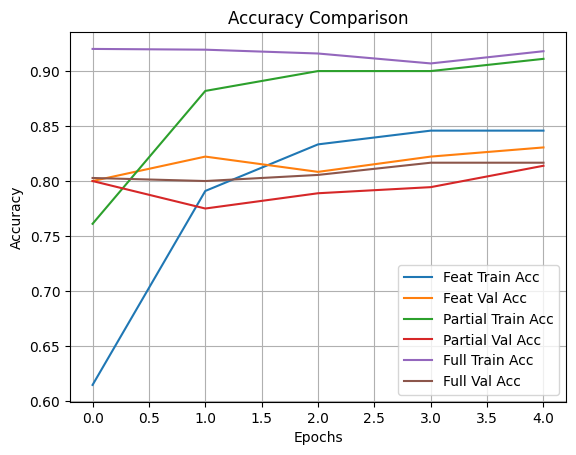

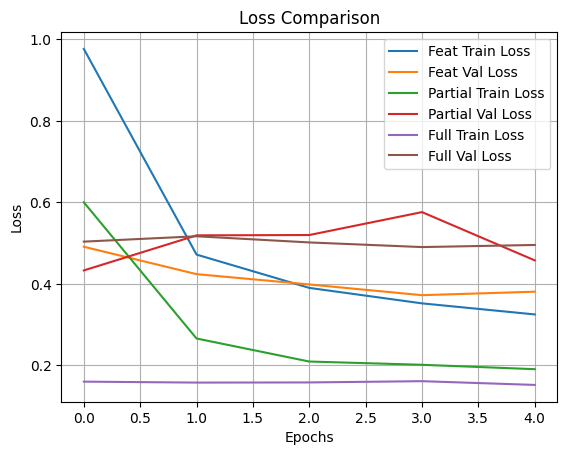

In [14]:
import matplotlib.pyplot as plt

# -----------------------------
# Accuracy Plot
# -----------------------------
plt.figure()

# Feature Extraction
plt.plot(history_mnv2_feat.history['accuracy'], label='Feat Train Acc')
plt.plot(history_mnv2_feat.history['val_accuracy'], label='Feat Val Acc')

# Partial Fine-Tuning
plt.plot(history_mnv2_part.history['accuracy'], label='Partial Train Acc')
plt.plot(history_mnv2_part.history['val_accuracy'], label='Partial Val Acc')

# Full Fine-Tuning
plt.plot(history_mnv2_full.history['accuracy'], label='Full Train Acc')
plt.plot(history_mnv2_full.history['val_accuracy'], label='Full Val Acc')

plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


# -----------------------------
# Loss Plot
# -----------------------------
plt.figure()

# Feature Extraction
plt.plot(history_mnv2_feat.history['loss'], label='Feat Train Loss')
plt.plot(history_mnv2_feat.history['val_loss'], label='Feat Val Loss')

# Partial Fine-Tuning
plt.plot(history_mnv2_part.history['loss'], label='Partial Train Loss')
plt.plot(history_mnv2_part.history['val_loss'], label='Partial Val Loss')

# Full Fine-Tuning
plt.plot(history_mnv2_full.history['loss'], label='Full Train Loss')
plt.plot(history_mnv2_full.history['val_loss'], label='Full Val Loss')

plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

### 4.4 Out-of-Distribution (OOD) Detection

In [18]:
import numpy as np

def detect_ood(model, dataset, known=True, threshold=0.6):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        max_probs = np.max(preds, axis=1)

        for i in range(len(max_probs)):

            y_true.append(1 if known else 0)

            if max_probs[i] < threshold:
                y_pred.append(0)  # OOD
            else:
                y_pred.append(1)  # Known

    return np.array(y_true), np.array(y_pred)

In [16]:
def prepare_ood_labels(dataset, known=True):
    y = []
    for _, labels in dataset:
        for l in labels:
            y.append(1 if known else 0)
    return np.array(y)

In [19]:
from sklearn.metrics import precision_score, recall_score

# Known data
y_true_k, y_pred_k = detect_ood(model_mnv2, val_ds, known=True, threshold=0.6)

# Unknown data
y_true_u, y_pred_u = detect_ood(model_mnv2, ood_ds, known=False, threshold=0.6)

# Combine
y_true = np.concatenate([y_true_k, y_true_u])
y_pred = np.concatenate([y_pred_k, y_pred_u])

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.36049107142857145
Recall: 0.8972222222222223


### 4.5 Evaluation

In [20]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_mnv2.predict(images, verbose=0)
    predicted_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [22]:
from sklearn.metrics import classification_report

labels = np.unique(y_true)
class_names = [f"Class {i}" for i in labels]

report = classification_report(y_true, y_pred, labels=labels, target_names=class_names)
print(report)

              precision    recall  f1-score   support

     Class 0       0.80      0.98      0.88        60
     Class 1       1.00      0.67      0.80        60
     Class 2       0.69      0.98      0.81        60
     Class 3       0.77      0.97      0.86        60
     Class 4       0.96      0.72      0.82        60
     Class 5       0.85      0.58      0.69        60

    accuracy                           0.82       360
   macro avg       0.85      0.82      0.81       360
weighted avg       0.85      0.82      0.81       360



In [23]:
from sklearn.metrics import f1_score, accuracy_score

macro_f1 = f1_score(y_true, y_pred, average='macro')
accuracy = accuracy_score(y_true, y_pred)

print("Macro F1 Score:", macro_f1)
print("Overall Accuracy:", accuracy)

Macro F1 Score: 0.81096105060187
Overall Accuracy: 0.8166666666666667


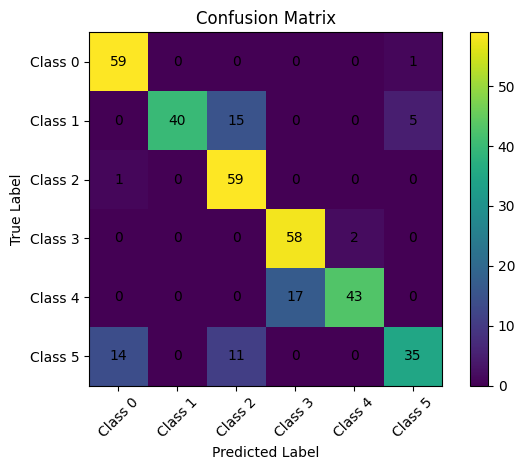

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

In [25]:
with open("requirements.txt", "w") as f:
    f.write("""tensorflow==2.15.0
numpy
matplotlib
scikit-learn""")